# Avazu CTR Dataset — Exploratory Data Analysis

Dataset: [Avazu Click-Through Rate Prediction](https://www.kaggle.com/datasets/atirpetkar/avazu-ctr)  
Goal: Understand feature distributions, class imbalance, time patterns, and cardinality before modeling.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

TRAIN_PATH = '../data/processed/train.csv'
SAMPLE_N   = 2_000_000   # use a sample for fast EDA; set None to use all rows

## 1. Load Data

In [8]:
df = pd.read_csv(TRAIN_PATH, dtype={'hour': str})
if SAMPLE_N:
    df = df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

print(f'Shape : {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape : (2000000, 24)
Memory: 1364.0 MB


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.479469e+19,0,14102209,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,21768,320,50,2506,0,35,-1,157
1,8.114817e+18,0,14102508,1005,1,a7853007,7e091613,f028772b,ecad2386,7801e8d9,...,1,0,22288,320,50,2572,3,297,100156,42
2,1.476297e+19,0,14102105,1005,0,6256f5b4,28f93029,f028772b,ecad2386,7801e8d9,...,1,0,21664,320,50,2492,3,35,-1,43


## 2. Basic Info — Nulls & Dtypes

In [9]:
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulls'   : df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2),
    'nunique' : df.nunique(),
})
info

,dtype,nulls,null_pct,nunique
id,float64,0,0.0,2000000
click,int64,0,0.0,2
hour,object,0,0.0,177
C1,int64,0,0.0,7
banner_pos,int64,0,0.0,7
site_id,object,0,0.0,3017
site_domain,object,0,0.0,3576
site_category,object,0,0.0,22
app_id,object,0,0.0,3899
app_domain,object,0,0.0,240


## 3. Class Imbalance — Click Distribution

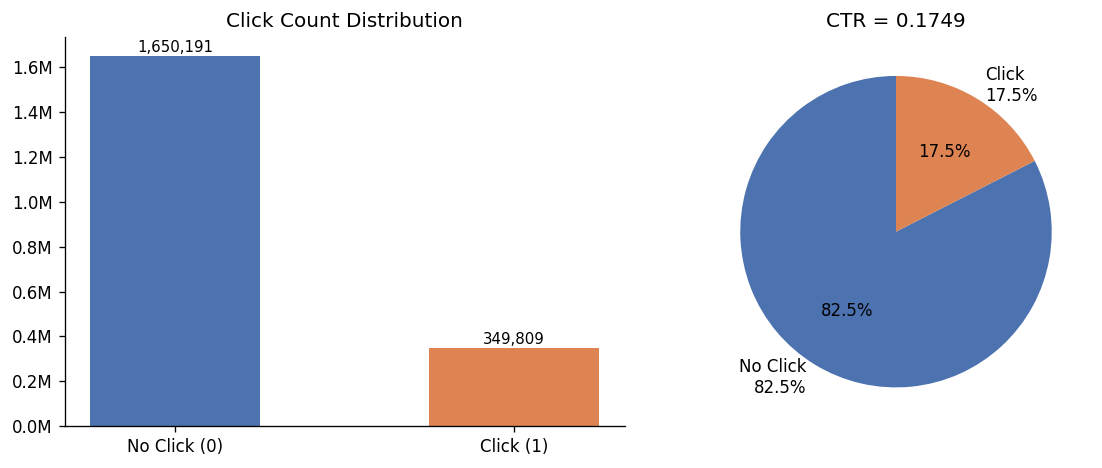

Class ratio (0:1) = 4.7:1  →  significant imbalance, use log-loss not accuracy


In [10]:
ctr = df['click'].mean()
counts = df['click'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No Click (0)', 'Click (1)'], counts.values, color=['#4c72b0', '#dd8452'], width=0.5)
axes[0].set_title('Click Count Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + counts.values.max() * 0.01, f'{v:,}', ha='center', fontsize=9)

axes[1].pie([1 - ctr, ctr], labels=[f'No Click\n{1-ctr:.1%}', f'Click\n{ctr:.1%}'],
            colors=['#4c72b0', '#dd8452'], autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'CTR = {ctr:.4f}')

plt.tight_layout()
plt.show()
print(f'Class ratio (0:1) = {counts[0]/counts[1]:.1f}:1  →  significant imbalance, use log-loss not accuracy')

## 4. Time Patterns

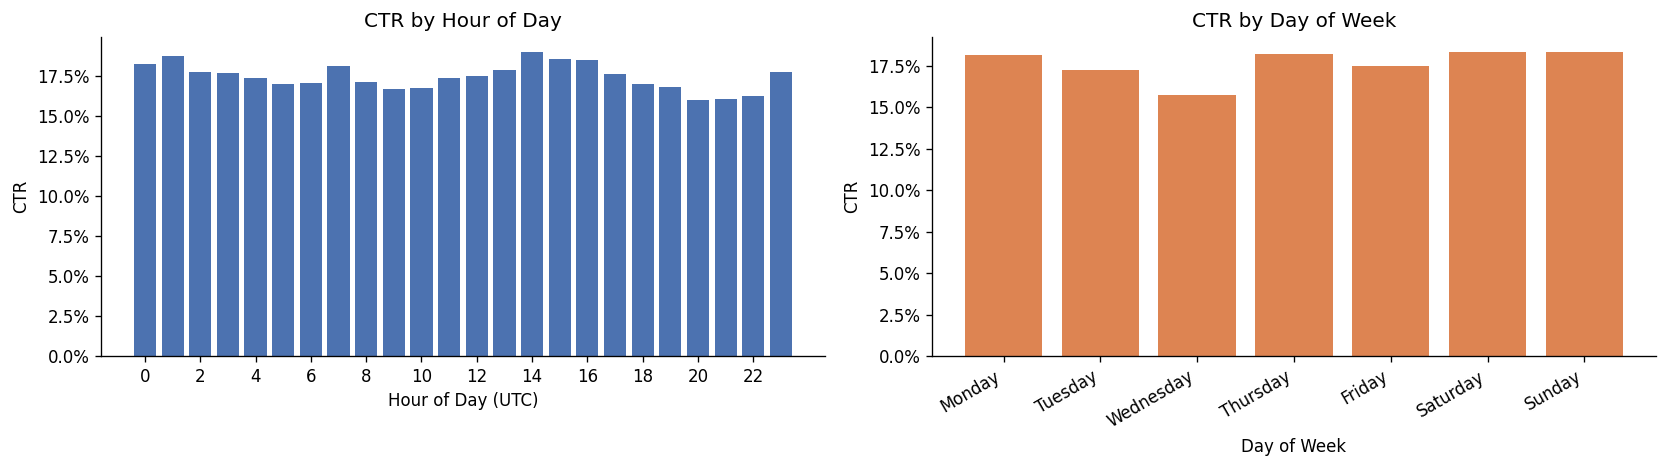

In [11]:
df['hour_of_day'] = df['hour'].str[-2:].astype(int)
df['day_of_week'] = pd.to_datetime(df['hour'].str[:6], format='%y%m%d').dt.day_name()

DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hour-of-day CTR
hod = df.groupby('hour_of_day')['click'].agg(['mean', 'count']).reset_index()
axes[0].bar(hod['hour_of_day'], hod['mean'], color='#4c72b0')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('CTR')
axes[0].set_title('CTR by Hour of Day')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
axes[0].set_xticks(range(0, 24, 2))

# Day-of-week CTR
dow = df.groupby('day_of_week')['click'].mean().reindex(DOW_ORDER)
axes[1].bar(DOW_ORDER, dow.values, color='#dd8452')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('CTR')
axes[1].set_title('CTR by Day of Week')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 5. Cardinality Analysis — High vs Low Cardinality Columns

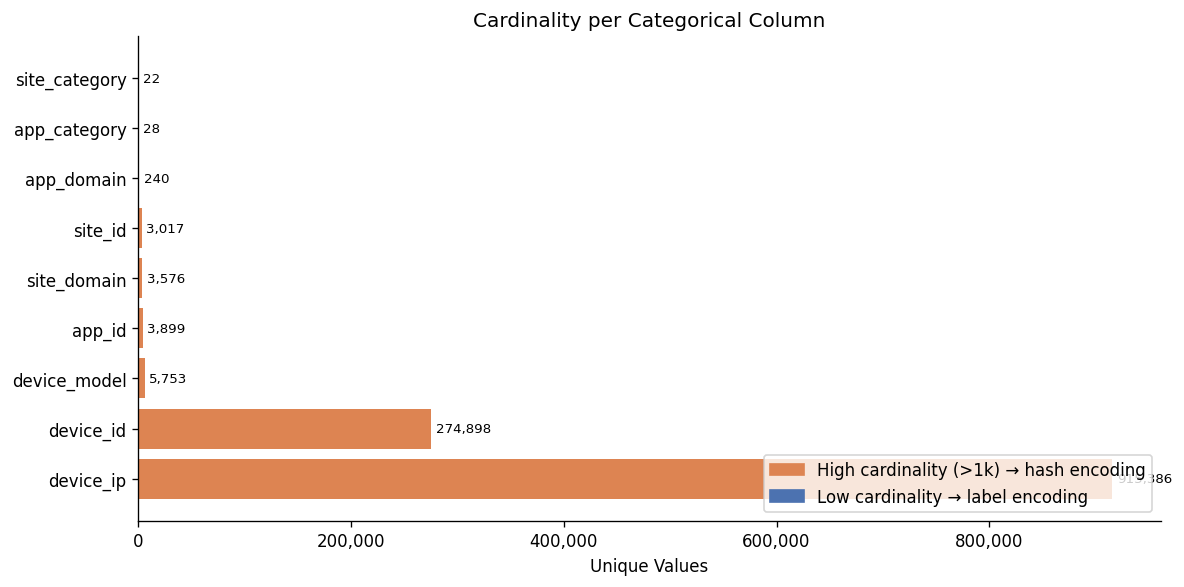


High-cardinality columns (>1k unique): ['device_ip', 'device_id', 'device_model', 'app_id', 'site_domain', 'site_id']
Low-cardinality  columns (≤1k unique): ['app_domain', 'app_category', 'site_category']


In [13]:
cat_cols = ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
            'app_category', 'device_id', 'device_ip', 'device_model']

cardinality = df[cat_cols].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cardinality.index, cardinality.values,
               color=['#dd8452' if v > 1000 else '#4c72b0' for v in cardinality.values])
ax.set_xlabel('Unique Values')
ax.set_title('Cardinality per Categorical Column')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, cardinality.values):
    ax.text(val + cardinality.max() * 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#dd8452', label='High cardinality (>1k) → hash encoding'),
    Patch(color='#4c72b0', label='Low cardinality → label encoding'),
], loc='lower right')

plt.tight_layout()
plt.show()

print('\nHigh-cardinality columns (>1k unique):', cardinality[cardinality > 1000].index.tolist())
print('Low-cardinality  columns (≤1k unique):', cardinality[cardinality <= 1000].index.tolist())

## 6. CTR by Key Categorical Features

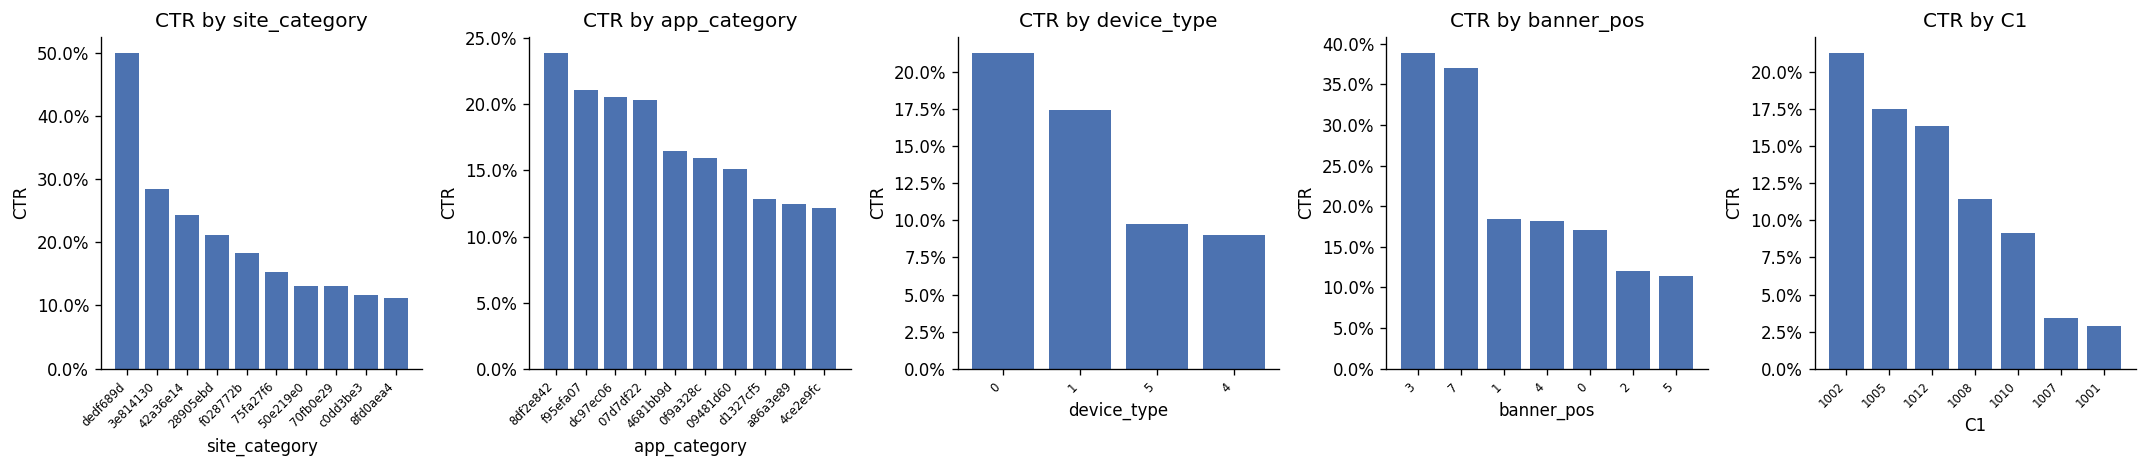

In [14]:
low_card = ['site_category', 'app_category', 'device_type', 'banner_pos', 'C1']

fig, axes = plt.subplots(1, len(low_card), figsize=(18, 4))

for ax, col in zip(axes, low_card):
    stats = df.groupby(col)['click'].agg(['mean', 'count']).reset_index()
    stats = stats.sort_values('mean', ascending=False).head(10)
    ax.bar(stats[col].astype(str), stats['mean'], color='#4c72b0')
    ax.set_title(f'CTR by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('CTR')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

## 7. Numeric Feature Distributions

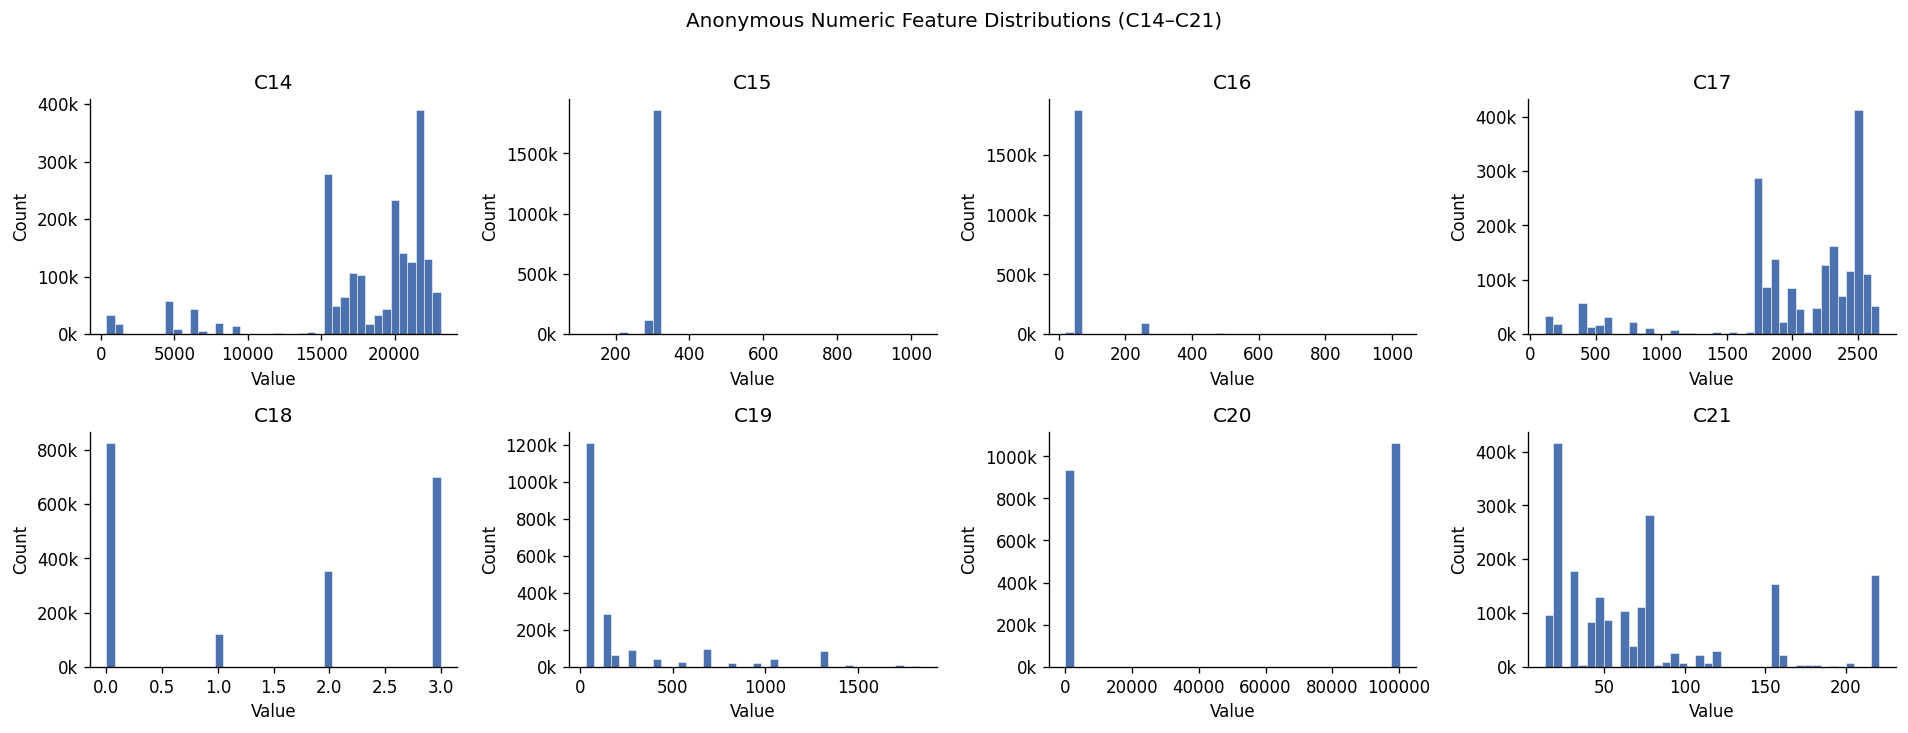

In [15]:
num_cols = ['C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col].clip(lower=0), bins=40, color='#4c72b0', edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.suptitle('Anonymous Numeric Feature Distributions (C14–C21)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 8. Interaction Features — Site × Device CTR Heatmap

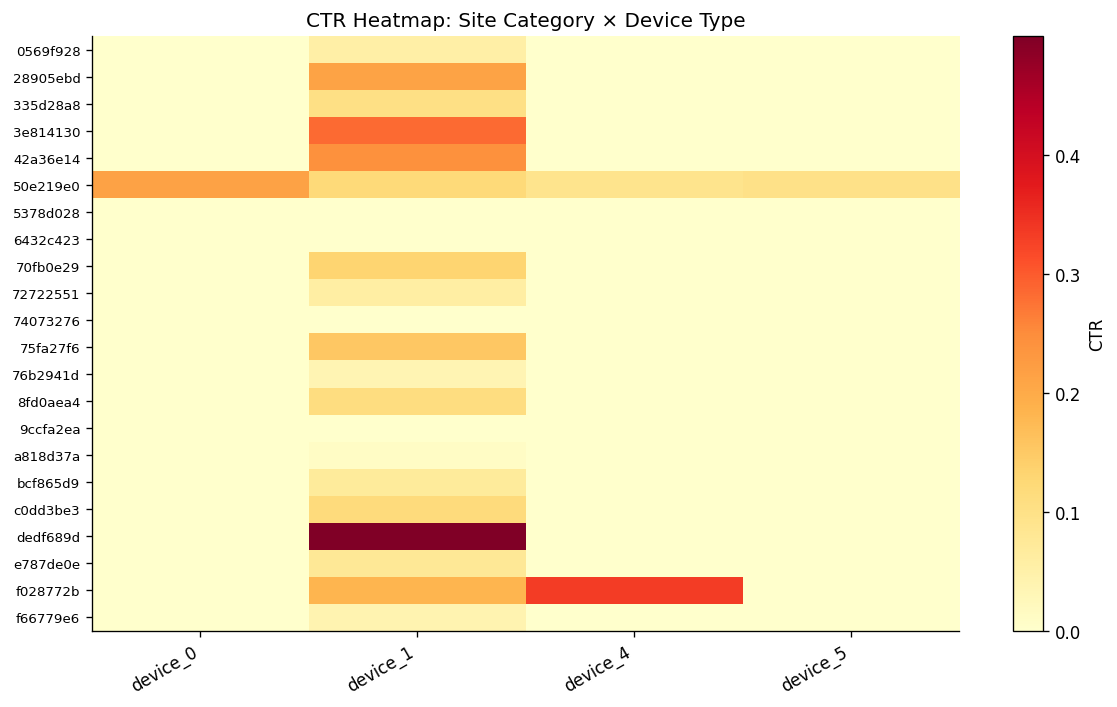

In [16]:
pivot = (
    df.groupby(['site_category', 'device_type'])['click']
    .mean()
    .unstack('device_type')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='CTR')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'device_{c}' for c in pivot.columns], rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title('CTR Heatmap: Site Category × Device Type')
plt.tight_layout()
plt.show()

## 9. Key Takeaways

| Finding | Implication |
|---------|-------------|
| CTR ≈ 17% — moderate imbalance | Use **log-loss** as primary metric, not accuracy |
| `device_id`, `device_ip` have very high cardinality | **Hash encoding** into 2^18 buckets |
| CTR varies strongly by hour-of-day | `hour_of_day` is a strong feature |
| `site_category` × `device_type` interaction shows variance | `site_x_device` interaction feature is justified |
| C14–C21 are anonymous integers with skewed distributions | Pass through as numeric; LightGBM handles natively |